## Figure S4. UHVDB dereplication strategy

In [ ]:
%%bash
### Download UHGV HQ HC genomes
wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_hq_plus.fna.gz

In [ ]:
%%bash
# align all-v-all using UHGV
vclust \
    prefilter \
    --in ../figure_1/uhgv_hq_plus.fna.gz \
    --out uhgv_hq_plus.prefilter.txt \
    --threads 24 \
    --min-ident 0.95

vclust \
    align \
    --in ../figure_1/uhgv_hq_plus.fna.gz \
    --out uhgv_hq_plus.ani.tsv \
    --filter uhgv_hq_plus.prefilter.txt \
    --threads 24 \
    --out-ani 0.95 \
    --out-qcov 0.85

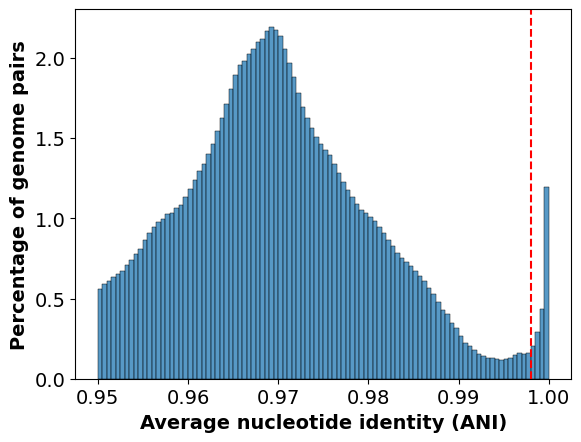

In [1]:
### plot ANI distribution 
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'font.size': 14})
 
ani = pl.read_csv("uhgv_hq_plus.ani.tsv", separator="\t")
plt.axvline(x=0.998, color="red", linestyle="--")
sns.histplot(ani["ani"], bins=100, stat='percent')
plt.xlabel("Average nucleotide identity (ANI)", fontdict={'fontweight': 'bold'})
plt.ylabel("Percentage of genome pairs", fontdict={'fontweight': 'bold'})
plt.show()

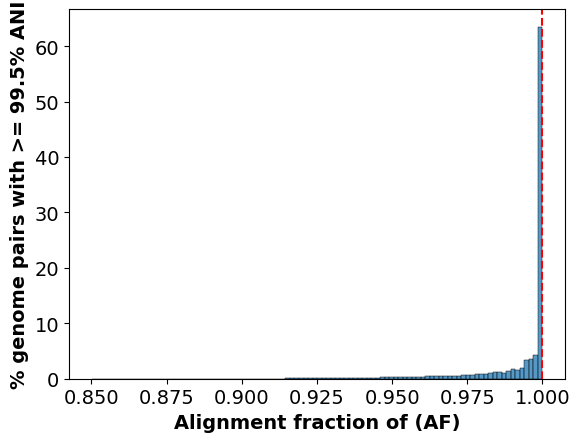

In [2]:
### plot AF (relative to query) distribution for genomes with >= 99.5% ANI
sns.histplot(ani.filter(pl.col('ani') >= 0.998)['qcov'], bins=100, stat='percent')
plt.xlabel("Alignment fraction of (AF)", fontdict={'fontweight': 'bold'})
plt.ylabel("% genome pairs with >= 99.5% ANI", fontdict={'fontweight': 'bold'})
plt.axvline(x=1.0, color="red", linestyle="--")
plt.show()

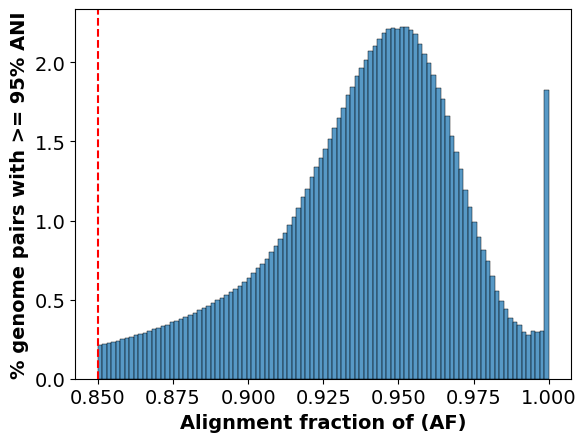

In [3]:
### plot AF (relative to query) distribution for genomes with >= 95% ANI
sns.histplot(ani.filter(pl.col('ani') >= 0.95)['qcov'], bins=100, stat='percent')
plt.xlabel("Alignment fraction of (AF)", fontdict={'fontweight': 'bold'})
plt.ylabel("% genome pairs with >= 95% ANI", fontdict={'fontweight': 'bold'})
plt.axvline(x=0.85, color="red", linestyle="--")
plt.show()

In [ ]:
import polars as pl

v4_unique = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')
v4_genomovars = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
print("Num v4 hashes:", v4_unique.height)
print("Num v4 unique:", v4_unique.unique('hash').height, "\n")
print("Num v4 genomovars reps:", v4_genomovars.unique('votu_rep').height)

Num v4 hashes: 760806
Num v4 unique: 575497 

Num v4 genomovars reps: 508382
